In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/Pokemon.csv")
df

,number,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,3,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067,896,Glastrier,Ice,NaN,580,100,145,130,65,110,30,8,True
1068,897,Spectrier,Ghost,NaN,580,100,65,60,145,80,130,8,True
1069,898,Calyrex,Psychic,Grass,500,100,80,80,80,80,80,8,True
1070,898,Ice Rider Calyrex,Psychic,Ice,680,100,165,150,85,130,50,8,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1072 entries, 0 to 1071
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   number      1072 non-null   int64
 1   name        1072 non-null   str  
 2   type1       1072 non-null   str  
 3   type2       574 non-null    str  
 4   total       1072 non-null   int64
 5   hp          1072 non-null   int64
 6   attack      1072 non-null   int64
 7   defense     1072 non-null   int64
 8   sp_attack   1072 non-null   int64
 9   sp_defense  1072 non-null   int64
 10  speed       1072 non-null   int64
 11  generation  1072 non-null   int64
 12  legendary   1072 non-null   bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 120.3 KB


In [4]:
df = pd.DataFrame(df)
column_list = list(df.columns)
column_list

['number',
 'name',
 'type1',
 'type2',
 'total',
 'hp',
 'attack',
 'defense',
 'sp_attack',
 'sp_defense',
 'speed',
 'generation',
 'legendary']

In [5]:
df.drop(columns='number',inplace=True)
df.head()

,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,Mega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Gigantamax Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


In [6]:
df.tail()

,name,type1,type2,total,hp,attack,defense,sp_attack,sp_defense,speed,generation,legendary
1067,Glastrier,Ice,NaN,580,100,145,130,65,110,30,8,True
1068,Spectrier,Ghost,NaN,580,100,65,60,145,80,130,8,True
1069,Calyrex,Psychic,Grass,500,100,80,80,80,80,80,8,True
1070,Ice Rider Calyrex,Psychic,Ice,680,100,165,150,85,130,50,8,True
1071,Shadow Rider Calyrex,Psychic,Ghost,680,100,85,80,165,100,150,8,True


In [7]:
df['type1'] = df['type1'].replace('Blastoise', 'Water') # blatoise is mistakenly in type1
df['name'] = df['name'].replace('Gigantamax Blasoise', 'Gigantamax Blastoise') # wrong spelling
df.loc[df['name'] == 'Gigantamax Blastoise', 'type2'] = 'None'
print(df[df['name'] == 'Gigantamax Blastoise'][['name','type1','type2']])

                    name  type1 type2
15  Gigantamax Blastoise  Water  None


In [8]:
df['generation'] = df['generation'].replace(0,1) #noticed the min value is 0

In [9]:
df.describe()

,total,hp,attack,defense,sp_attack,sp_defense,speed,generation
count,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000
mean,440.885261,70.486940,80.938433,74.968284,73.273321,72.476679,68.792910,4.297575
std,121.379077,26.868039,32.463582,31.208059,32.643119,27.934253,30.076281,2.341936
min,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000
25%,330.000000,50.000000,56.000000,52.000000,50.000000,50.000000,45.000000,2.000000
50%,460.500000,68.000000,80.000000,70.000000,65.000000,70.000000,65.000000,4.000000
75%,519.250000,84.000000,100.000000,90.000000,95.000000,90.000000,90.000000,6.000000
max,1125.000000,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000,8.000000


In [10]:
# replace N/A in the type2 column
df['type2'] = df['type2'].fillna('None')

In [11]:
df['type1'] = df['type1'].replace('Graass','Grass')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

name          0
type1         0
type2         0
total         0
hp            0
attack        0
defense       0
sp_attack     0
sp_defense    0
speed         0
generation    0
legendary     0
dtype: int64

In [14]:
df.nunique()

name          1072
type1           18
type2           19
total          219
hp             103
attack         123
defense        114
sp_attack      119
sp_defense     107
speed          127
generation       8
legendary        2
dtype: int64

# Data Visualization

## Overview

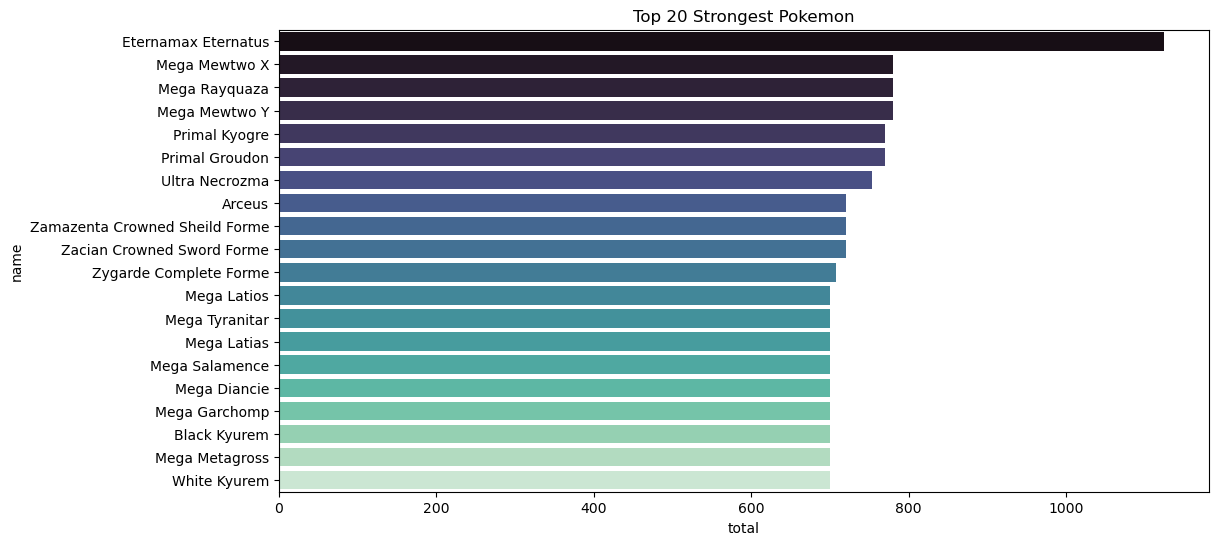

In [15]:
top20 = df.sort_values('total', ascending=False).head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x='total',
    y='name',
    data=top20,
    palette='mako'
)

plt.title('Top 20 Strongest Pokemon')
plt.show()

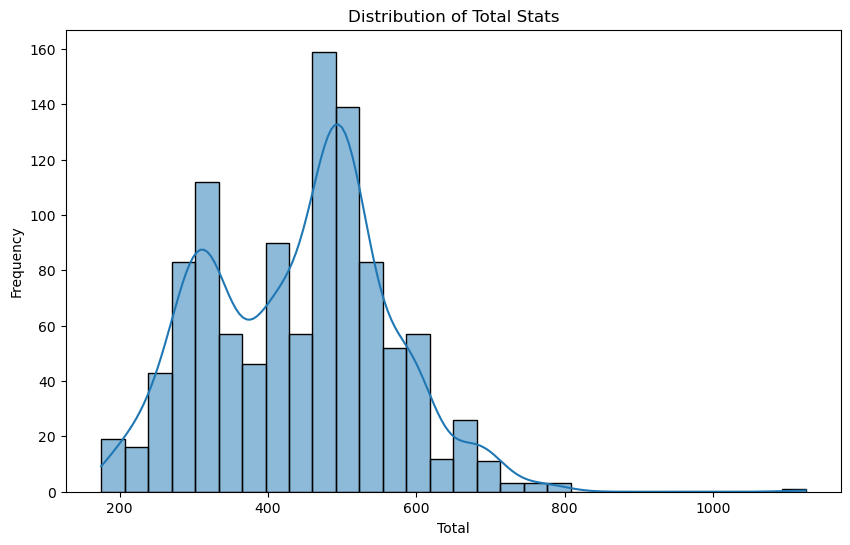

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total', bins=30, kde=True)

plt.title('Distribution of Total Stats')
plt.xlabel('Total')
plt.ylabel('Frequency')
plt.show()

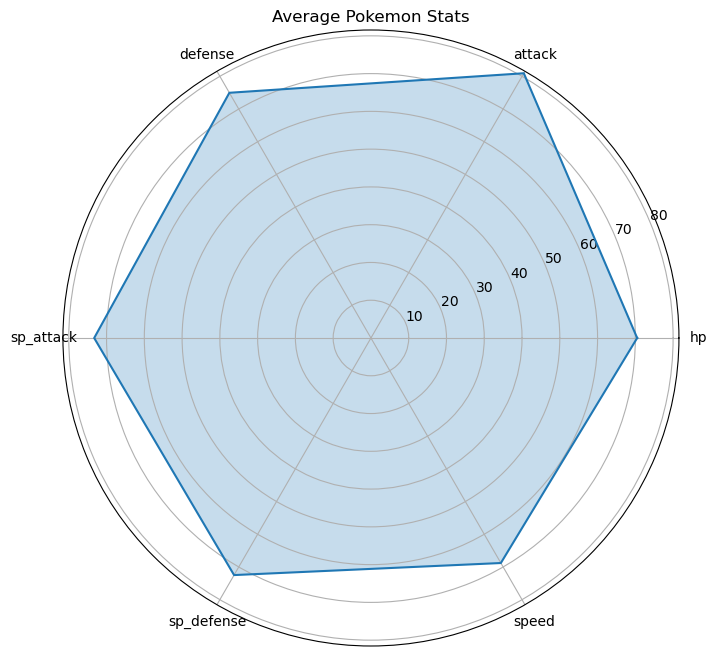

In [17]:
stats = ['hp','attack','defense', 'sp_attack','sp_defense','speed']

average_stats = df[stats].mean()

label_placement = np.linspace(
    start=0,
    stop=2*np.pi,
    num=len(average_stats),
    endpoint=False,
).tolist()

values = average_stats.tolist()

#6 items + hp = 7 items
plot_values = values + values[:1] 
plot_angles = label_placement + label_placement[:1]

plt.figure(figsize=(8,8))
plt.subplot(polar=True)
plt.plot(plot_angles, plot_values)
plt.fill(plot_angles, plot_values, alpha=0.25) #alpha for transparency

plt.thetagrids(np.degrees(label_placement), labels=stats) 

plt.title('Average Pokemon Stats')
plt.show()


### Distribution of Elemental Types

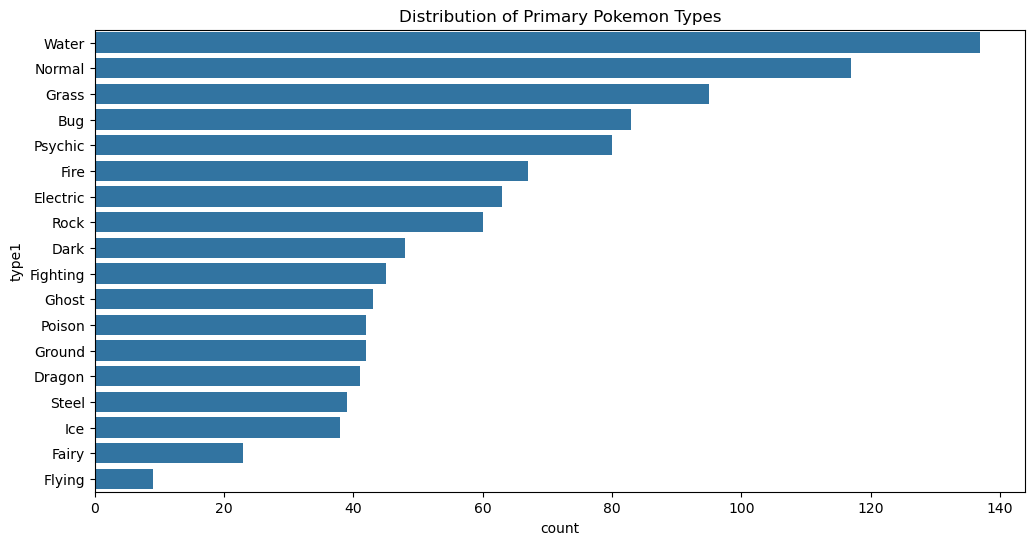

type1
Water       137
Normal      117
Grass        95
Bug          83
Psychic      80
Fire         67
Electric     63
Rock         60
Dark         48
Fighting     45
Ghost        43
Poison       42
Ground       42
Dragon       41
Steel        39
Ice          38
Fairy        23
Flying        9
Name: count, dtype: int64


In [18]:
primary_type_counts = df['type1'].value_counts()

plt.figure(figsize=(12,6))
sns.countplot(y='type1', data=df, order=primary_type_counts.index)
plt.title("Distribution of Primary Pokemon Types")
plt.show()

print(primary_type_counts)

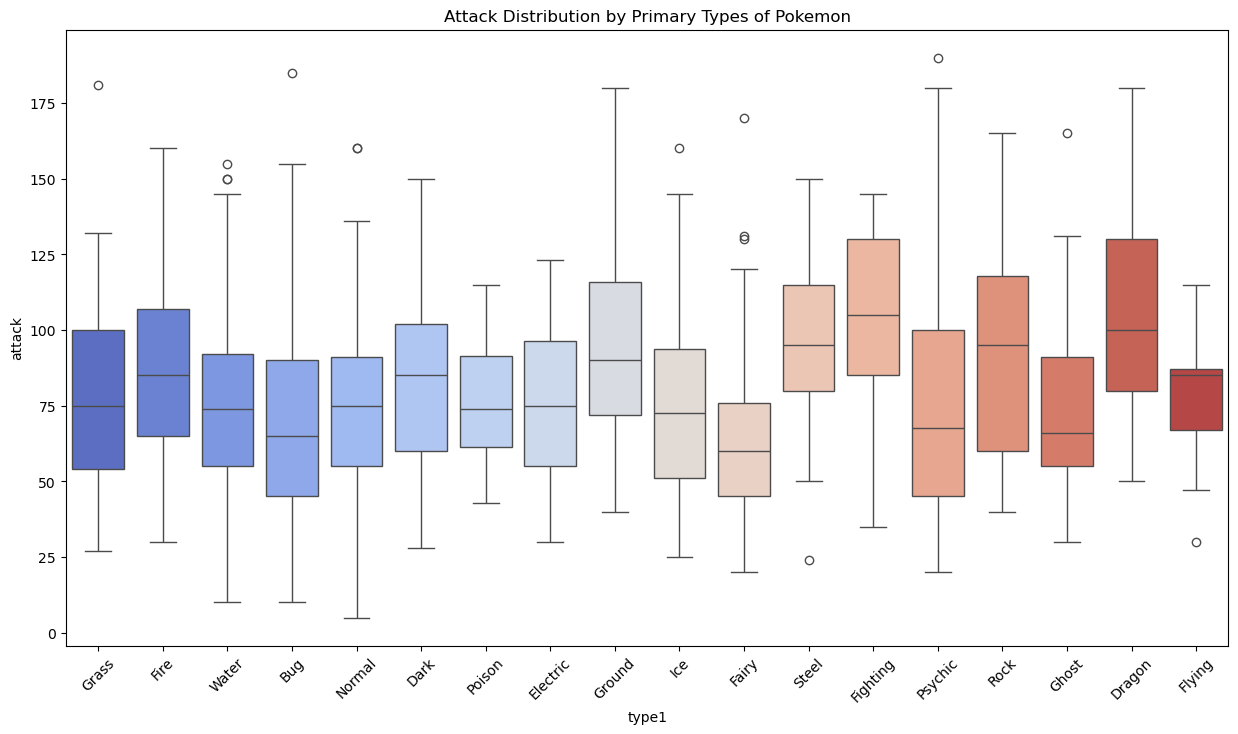

In [19]:
plt.figure(figsize=(15,8))

sns.boxplot(
    x='type1',
    y='attack',
    data=df,
    palette='coolwarm'
)

plt.title('Attack Distribution by Primary Types of Pokemon')
plt.xticks(rotation=45)
plt.show()

### Generation Trends

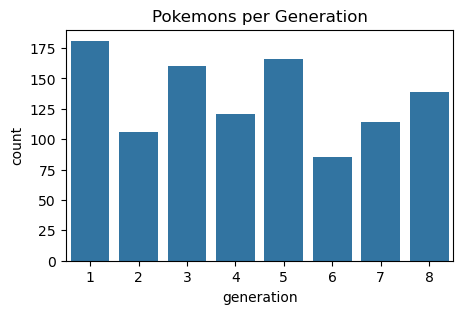

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))
sns.countplot(data=df, x="generation", ax=ax)

plt.title("Pokemons per Generation")
plt.show()

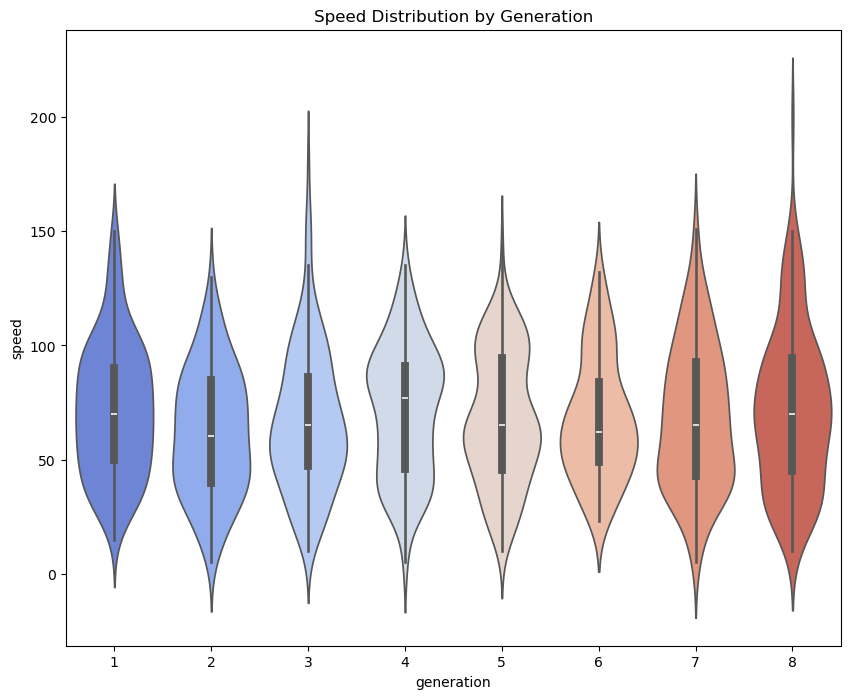

In [21]:
plt.figure(figsize=(10,8))

sns.violinplot(
    x='generation',
    y='speed',
    data=df,
    palette='coolwarm'
)

plt.title('Speed Distribution by Generation')
plt.show()

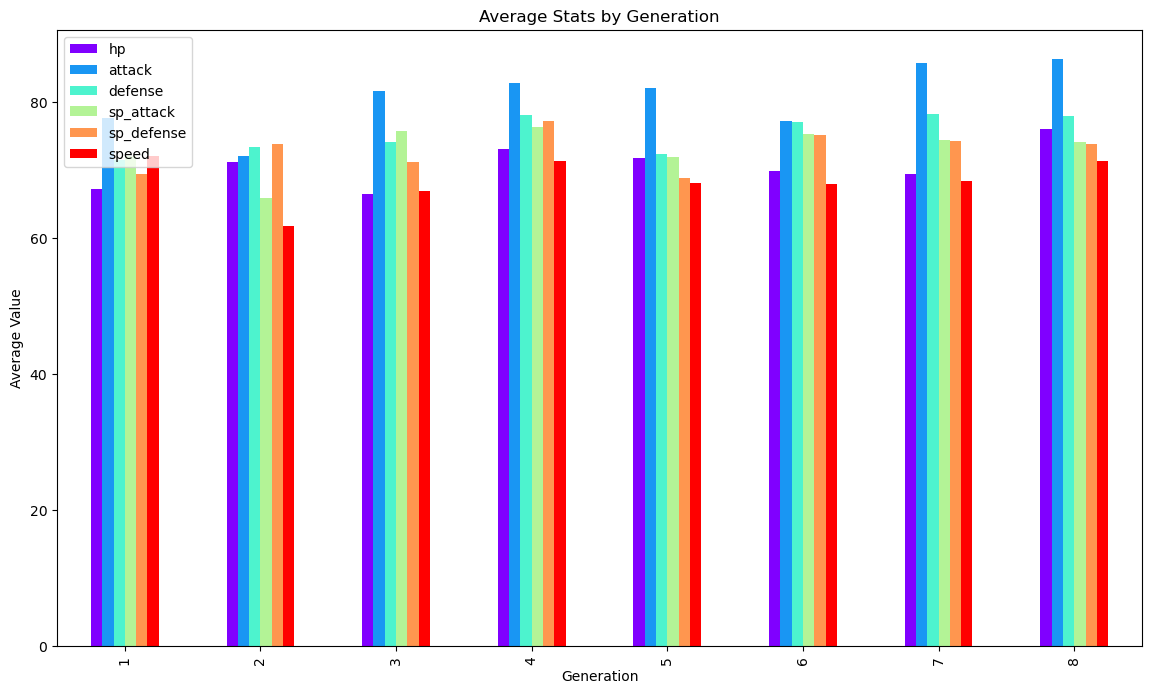

In [22]:
stats = [
    "hp",
    "attack",
    "defense",
    "sp_attack",
    "sp_defense",
    "speed"
]

gen_stats = df.groupby('generation')[stats].mean()

gen_stats.plot(
    kind='bar',
    figsize=(14,8),
    colormap='rainbow'
)

plt.title('Average Stats by Generation')
plt.ylabel('Average Value')
plt.xlabel('Generation')
plt.show()


### Correlations between Attributes

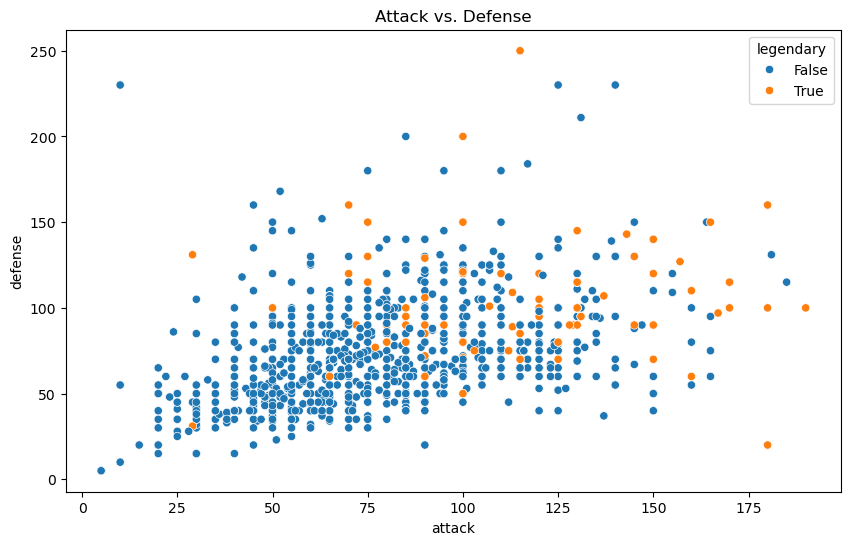

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="attack",
    y="defense",
    hue="legendary"
)

plt.title("Attack vs. Defense")
plt.show()

In [24]:
df["attack"].corr(df["defense"])

np.float64(0.46060323862634805)

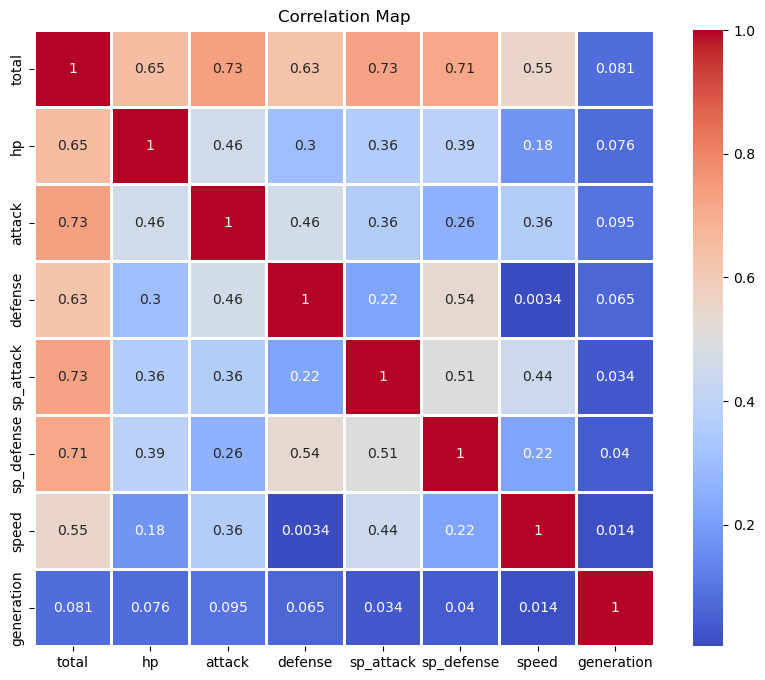

In [25]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    linewidths=True,
    cmap='coolwarm'
)

plt.title("Correlation Map")
plt.show()

### Legendary Pokemon Stats

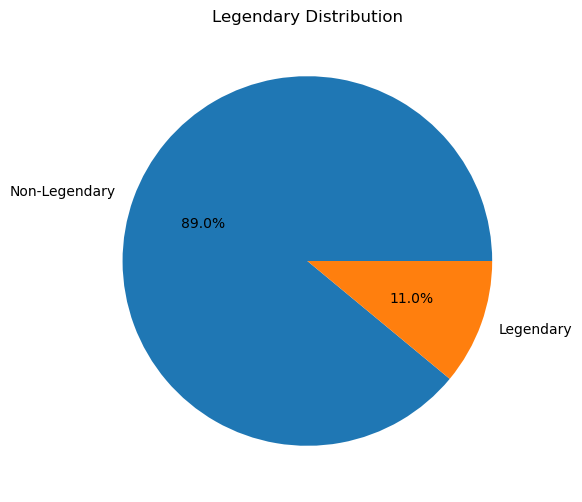

legendary
False    954
True     118
Name: count, dtype: int64


In [26]:
legendary_counts = df["legendary"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    legendary_counts,
    labels= ['Non-Legendary', 'Legendary'],
    autopct='%1.1f%%',
)

plt.title("Legendary Distribution")
plt.show()

print(legendary_counts)

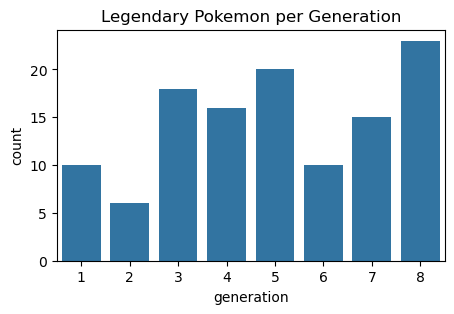

In [27]:
generation_stats = (
    df[df['legendary']].groupby('generation').size().reset_index(name='count')
)

fig, ax = plt.subplots(1, 1, figsize=(5,3))
sns.barplot(data=generation_stats, x='generation', y='count', ax=ax)

plt.title("Legendary Pokemon per Generation")
plt.show()

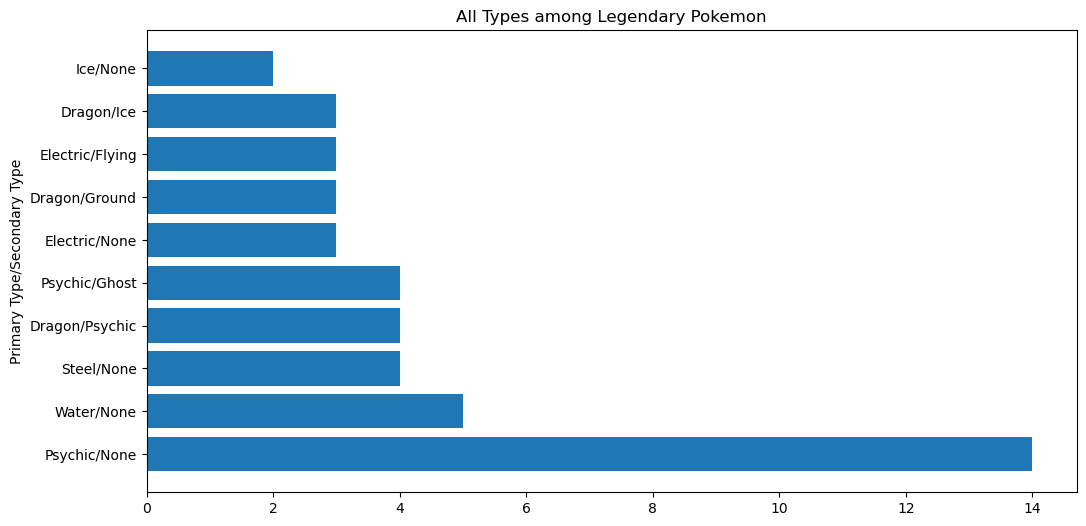

type1     type2  
Psychic   None       14
Water     None        5
Steel     None        4
Dragon    Psychic     4
Psychic   Ghost       4
Electric  None        3
Dragon    Ground      3
Electric  Flying      3
Dragon    Ice         3
Ice       None        2
dtype: int64


In [28]:
legendary_types = (
    df[df['legendary']]
    .groupby(['type1','type2'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

labels = [
    f"{t1}/{t2}"
    for t1, t2 in legendary_types.index
]

plt.figure(figsize=(12,6))
plt.barh(labels, legendary_types.values)

plt.ylabel('Primary Type/Secondary Type')
plt.title('All Types among Legendary Pokemon')
plt.show()
print(legendary_types)

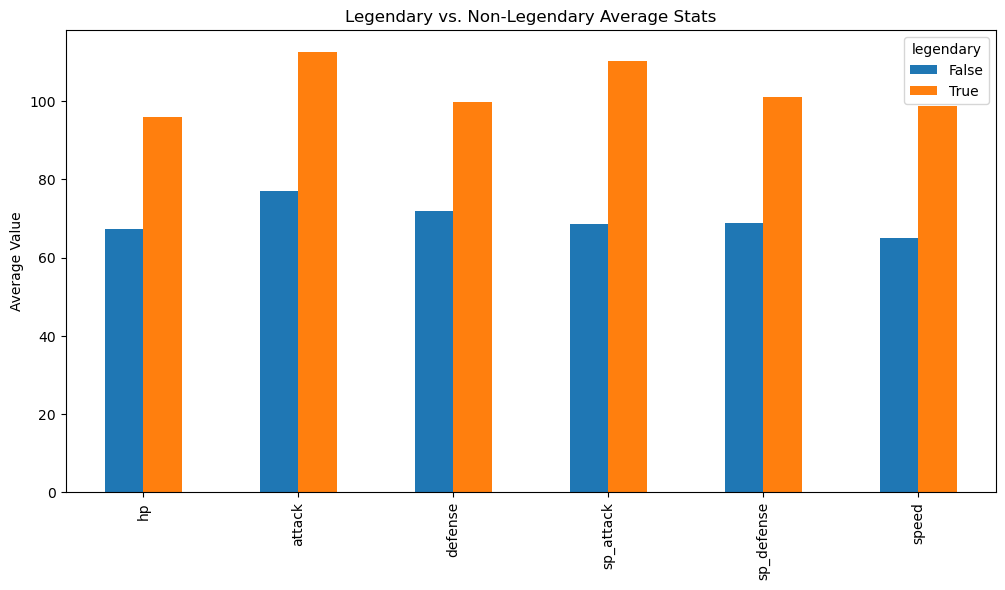

In [29]:
stats = [
    "hp",
    "attack",
    "defense",
    "sp_attack",
    "sp_defense",
    "speed"
]

legendary_stats = df.groupby('legendary')[stats].mean().T  #T means transpose

legendary_stats.plot(
    kind='bar',
    figsize=(12,6),
)

plt.title('Legendary vs. Non-Legendary Average Stats')
plt.ylabel('Average Value')
plt.show()

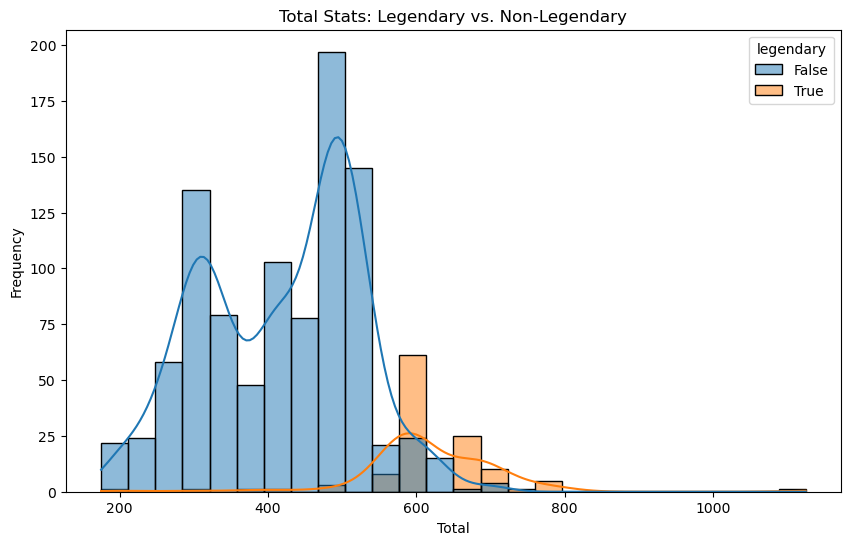

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total', hue='legendary', kde=True)

plt.title('Total Stats: Legendary vs. Non-Legendary')
plt.xlabel('Total')
plt.ylabel('Frequency')
plt.show()

## Training/Machine Learning

In [31]:
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

In [32]:
X= df.drop(columns="legendary")
y = df["legendary"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)

X Train Shape: (857, 11)
X Test Shape: (215, 11)


In [33]:
categorical_cols = [
    'name',
    'type1',
    'type2'
]

numerical_cols = [
    'total',
    'hp',
    'attack',
    'defense',
    'sp_attack',
    'sp_defense',
    'speed',
    'generation'
]

In [34]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [35]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_train_scaled

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9427 stored elements and shape (857, 902)>

In [36]:
X_test_scaled = preprocessor.transform(X_test)
X_test_scaled

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2150 stored elements and shape (215, 902)>

In [37]:
log_reg = LogisticRegression(random_state=0).fit(X_train_scaled, y_train)

In [38]:
log_reg.predict(X_train_scaled)

array([False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False,  True, False,  True, False, False, False, False,
       False,  True, False, False, False, False,  True, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False,

In [39]:
log_reg.score(X_train_scaled,y_train)

0.9754959159859977

# Export Final Model and Scalar

In [ ]:
import pickle

clf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', log_reg)
    ]
)

clf.fit(X_train, y_train)

pickle.dump(clf, open("models/production.sav", 'wb'))

FileNotFoundError: [Errno 2] No such file or directory: '../models/production.sav'